In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

print("Data preprocessing packages loaded successfully!")

Data preprocessing packages loaded successfully!


In [3]:
# Load the messy dataset
df = pd.read_csv('dataset/breast-cancer.csv')

# Display basic information
print("=== Dataset Info ===")
df.info()

# Display the first few rows
print("\n=== First 5 Rows ===")
display(df.head())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   no-recurrence-events  285 non-null    str  
 1   30-39                 285 non-null    str  
 2   premeno               285 non-null    str  
 3   30-34                 285 non-null    str  
 4   0-2                   285 non-null    str  
 5   no                    285 non-null    str  
 6   3                     285 non-null    int64
 7   left                  285 non-null    str  
 8   left_low              285 non-null    str  
 9   no.1                  285 non-null    str  
dtypes: int64(1), str(9)
memory usage: 22.4 KB

=== First 5 Rows ===


,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no.1
0,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
2,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
3,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
4,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,left,left_low,no


In [4]:
# 1. Strip extra quotes from column names
df.columns = df.columns.str.replace("'", "").str.strip()

# 2. Strip extra quotes from all string values in the DataFrame
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.replace("'", "").str.strip()

# Replace any string "nan" back to actual NaN values
df = df.replace('nan', np.nan)

# Display the cleaned column names and first few rows
print("=== Cleaned Column Names ===")
print(df.columns.tolist())

print("\n=== Cleaned First 5 Rows ===")
display(df.head())

# Check for missing values
print("\n=== Missing Values Count ===")
print(df.isnull().sum())

=== Cleaned Column Names ===
['no-recurrence-events', '30-39', 'premeno', '30-34', '0-2', 'no', '3', 'left', 'left_low', 'no.1']

=== Cleaned First 5 Rows ===


/tmp/ipykernel_635007/3239579009.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no.1
0,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
2,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
3,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
4,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,left,left_low,no



=== Missing Values Count ===
no-recurrence-events    0
30-39                   0
premeno                 0
30-34                   0
0-2                     0
no                      0
3                       0
left                    0
left_low                0
no.1                    0
dtype: int64


In [ ]:
# 1. Rename columns to standard, meaningful names based on UCI breast cancer attributes
rename_dict = {
    '40-49': 'age',
    'premeno': 'menopause',
    '15-19': 'tumor_size',
    '0-2': 'inv_nodes',
    'yes': 'node_caps',
    '4': 'deg_malig_placeholder',
    '3': 'deg_malig',
    'right': 'breast',
    'left_up': 'breast_quad',
    'no': 'irradiat',
    'recurrence-events': 'class'
}
df = df.rename(columns=rename_dict)

# 2. Impute missing values with the mode for categorical columns
for col in ['node_caps', 'breast_quad']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

# Display cleaned dataset overview
print("=== Missing Values After Imputation ===")
print(df.isnull().sum())

print("\n=== Fully Cleaned Dataset Preview ===")
display(df.head())

=== Missing Values After Imputation ===
age                      0
menopause                0
tumor_size               0
inv_nodes                0
node_caps                0
deg_malig_placeholder    0
deg_malig                0
breast                   0
breast_quad              0
irradiat                 0
class                    0
dtype: int64

=== Fully Cleaned Dataset Preview ===


,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig_placeholder,deg_malig,breast,breast_quad,irradiat,class
0,50-59,ge40,15-19,0-2,no,4,1,right,central,no,no-recurrence-events
1,50-59,ge40,35-39,0-2,no,4,2,left,left_low,no,recurrence-events
2,40-49,premeno,35-39,0-2,yes,4,3,right,left_low,yes,no-recurrence-events
3,40-49,premeno,30-34,3-5,yes,4,2,left,right_up,no,recurrence-events
4,50-59,premeno,25-29,3-5,no,4,2,right,left_up,yes,no-recurrence-events


=== Target Class Distribution ===
class
no-recurrence-events    204
recurrence-events        84
Name: count, dtype: int64


/tmp/ipykernel_3904/2410972637.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='viridis')


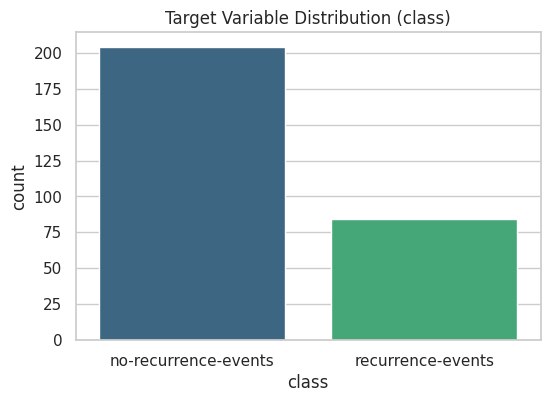

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Step 1: Analyze the target variable 'class'
print("=== Target Class Distribution ===")
print(df['class'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', palette='viridis')
plt.title('Target Variable Distribution (class)')
plt.show()

Next, let's look at the age groups of the patients in our dataset.

=== Age Group Distribution ===
age
50-59    97
40-49    90
60-69    57
30-39    37
70-79     6
20-29     1
Name: count, dtype: int64


/tmp/ipykernel_3904/2697213505.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age', order=sorted(df['age'].unique()), palette='crest')


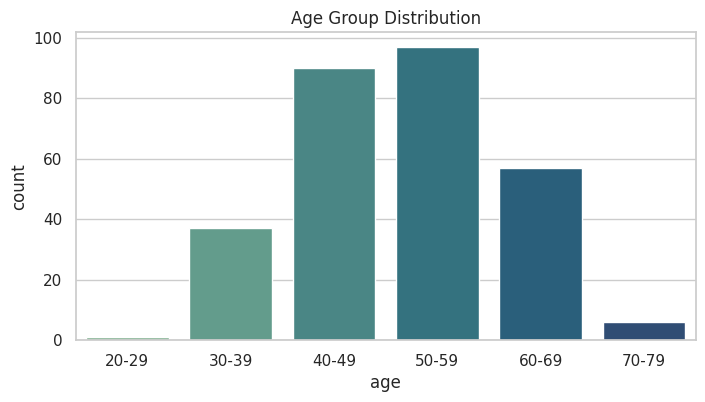

In [ ]:
# Step 2: Analyze the 'age' distribution
print("=== Age Group Distribution ===")
print(df['age'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='age', order=sorted(df['age'].unique()), palette='crest')
plt.title('Age Group Distribution')
plt.show()

Next, let's explore how the **Degree of Malignancy** relates to recurrence vs. non-recurrence classes.

=== Degree of Malignancy by Class ===
class     no-recurrence-events recurrence-events
deg_malig                                       
1                        83.1%             16.9%
2                       78.79%            21.21%
3                       48.24%            51.76%


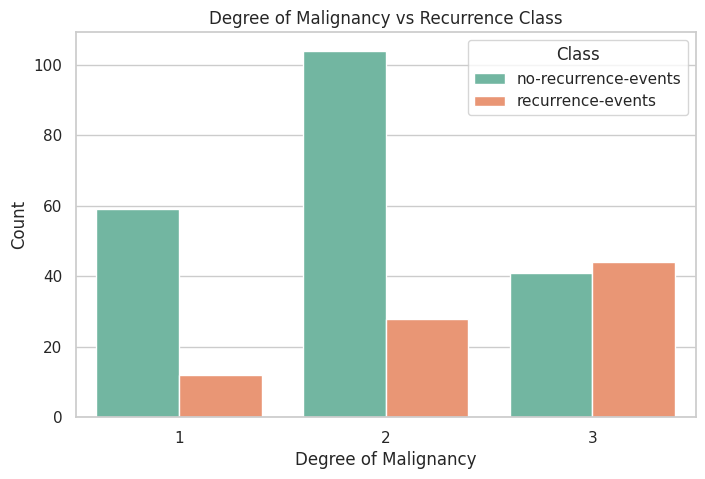

In [ ]:
# Step 3: Analyze the relationship between 'deg_malig' and 'class'
print("=== Degree of Malignancy by Class ===")
cross_tab = pd.crosstab(df['deg_malig'], df['class'], normalize='index') * 100
print(cross_tab.round(2).astype(str) + '%')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='deg_malig', hue='class', palette='Set2')
plt.title('Degree of Malignancy vs Recurrence Class')
plt.xlabel('Degree of Malignancy')
plt.ylabel('Count')
plt.legend(title='Class')
plt.show()

Next, let's explore how the **Degree of Malignancy** relates to recurrence vs. non-recurrence classes.

=== Degree of Malignancy by Class ===
class     no-recurrence-events recurrence-events
deg_malig                                       
1                        83.1%             16.9%
2                       78.79%            21.21%
3                       48.24%            51.76%


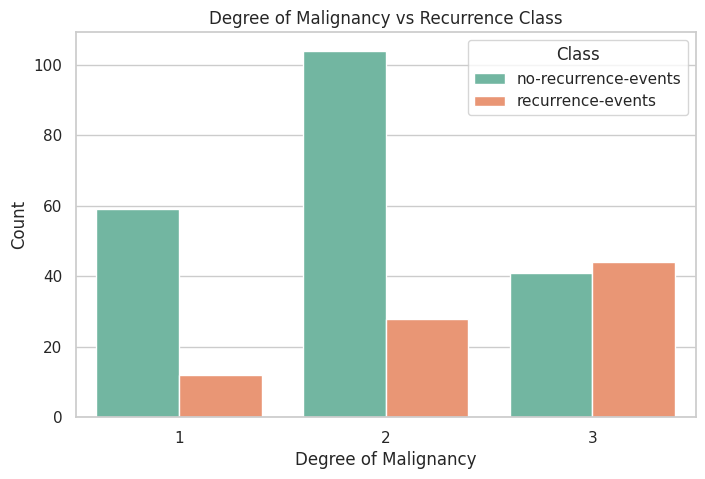

In [ ]:
# Step 3: Analyze the relationship between 'deg_malig' and 'class'
print("=== Degree of Malignancy by Class ===")
cross_tab = pd.crosstab(df['deg_malig'], df['class'], normalize='index') * 100
print(cross_tab.round(2).astype(str) + '%')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='deg_malig', hue='class', palette='Set2')
plt.title('Degree of Malignancy vs Recurrence Class')
plt.xlabel('Degree of Malignancy')
plt.ylabel('Count')
plt.legend(title='Class')
plt.show()

Finally, let's explore how **Tumor Size** relates to recurrence classes.

=== Tumor Size by Class ===
class      no-recurrence-events recurrence-events
tumor_size                                       
0-4                       87.5%             12.5%
10-14                    96.43%             3.57%
15-19                     80.0%             20.0%
20-24                    68.63%            31.37%
25-29                    66.67%            33.33%
30-34                    58.33%            41.67%
35-39                    63.16%            36.84%
40-44                    73.91%            26.09%
45-49                    66.67%            33.33%
5-9                      100.0%              0.0%
50-54                     62.5%             37.5%


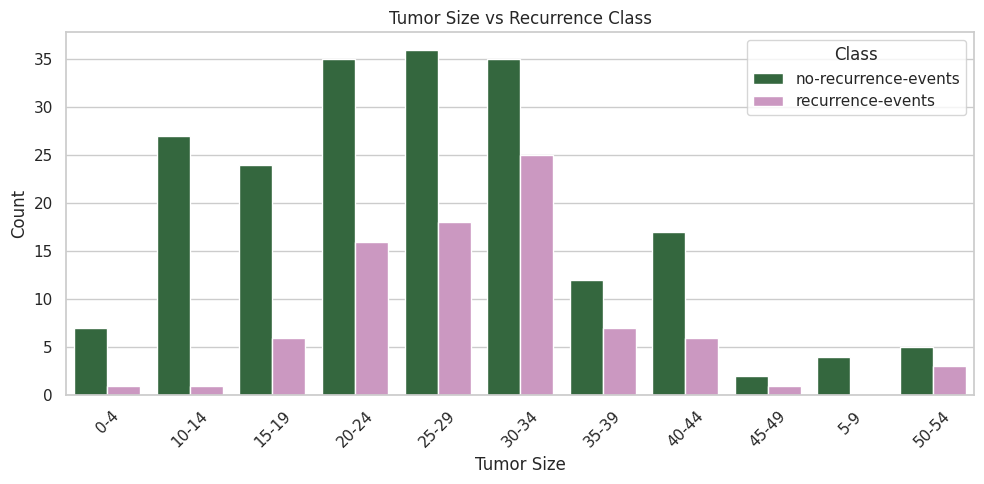

In [ ]:
# Step 5: Analyze the relationship between 'tumor_size' and 'class'
print("=== Tumor Size by Class ===")
tumor_cross = pd.crosstab(df['tumor_size'], df['class'], normalize='index') * 100
print(tumor_cross.round(2).astype(str) + '%')

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='tumor_size', hue='class', order=sorted(df['tumor_size'].unique()), palette='cubehelix')
plt.title('Tumor Size vs Recurrence Class')
plt.xlabel('Tumor Size')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

Let's explore how **Menopause State** relates to the recurrence class.

=== Menopause State by Class ===
class     no-recurrence-events recurrence-events
menopause                                       
ge40                    73.08%            26.92%
lt40                     75.0%             25.0%
premeno                 68.67%            31.33%


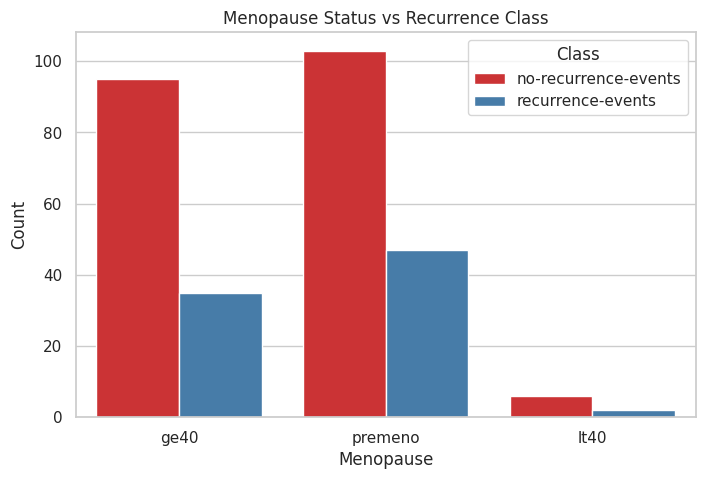

In [ ]:
# Step 4: Analyze the relationship between 'menopause' and 'class'
print("=== Menopause State by Class ===")
menopause_cross = pd.crosstab(df['menopause'], df['class'], normalize='index') * 100
print(menopause_cross.round(2).astype(str) + '%')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='menopause', hue='class', palette='Set1')
plt.title('Menopause Status vs Recurrence Class')
plt.xlabel('Menopause')
plt.ylabel('Count')
plt.legend(title='Class')
plt.show()

In [ ]:
df.head()

,age,menopause,tumor_size,inv_nodes,node_caps,deg_malig_placeholder,deg_malig,breast,breast_quad,irradiat,class
0,50-59,ge40,15-19,0-2,no,4,1,right,central,no,no-recurrence-events
1,50-59,ge40,35-39,0-2,no,4,2,left,left_low,no,recurrence-events
2,40-49,premeno,35-39,0-2,yes,4,3,right,left_low,yes,no-recurrence-events
3,40-49,premeno,30-34,3-5,yes,4,2,left,right_up,no,recurrence-events
4,50-59,premeno,25-29,3-5,no,4,2,right,left_up,yes,no-recurrence-events


In [ ]:
import pandas as pd
import numpy as np

# 1. Separate features and target
# Drop 'deg_malig_placeholder' as it was just an uninformative leftover column
X = df.drop(columns=['class', 'deg_malig_placeholder'])
y = df['class'].map({'no-recurrence-events': 0, 'recurrence-events': 1})

# 2. Identify categorical columns to encode
# We will perform One-Hot Encoding on all feature columns in X since they are categorical/binned strings
X_encoded = pd.get_dummies(X, drop_first=True)

# Convert boolean True/False outputs from get_dummies to integers (1/0)
X_encoded = X_encoded.astype(int)

print("=== Encoded Feature Shape ===")
print(X_encoded.shape)

print("\n=== Encoded Features Preview ===")
display(X_encoded.head())

print("\n=== Target Variable Distribution (0: No Recurrence, 1: Recurrence) ===")
print(y.value_counts())

=== Encoded Feature Shape ===
(288, 32)

=== Encoded Features Preview ===


,age_30-39,age_40-49,age_50-59,age_60-69,age_70-79,menopause_lt40,menopause_premeno,tumor_size_10-14,tumor_size_15-19,tumor_size_20-24,...,inv_nodes_9-11,node_caps_yes,deg_malig_2,deg_malig_3,breast_right,breast_quad_left_low,breast_quad_left_up,breast_quad_right_low,breast_quad_right_up,irradiat_yes
0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,0
2,0,1,0,0,0,0,1,0,0,0,...,0,1,0,1,1,1,0,0,0,1
3,0,1,0,0,0,0,1,0,0,0,...,0,1,1,0,0,0,0,0,1,0
4,0,0,1,0,0,0,1,0,0,0,...,0,0,1,0,1,0,1,0,0,1



=== Target Variable Distribution (0: No Recurrence, 1: Recurrence) ===
class
0    204
1     84
Name: count, dtype: int64
